## 2. Gün: Data Quality Analysis

Bu aşamada, ilk gün boyutlarını ve tiplerini incelediğimiz veri setinin sağlığını detaylı olarak analiz edeceğiz. Makine öğrenmesi modelleri verideki kirliliğe ve aykırı değerlere karşı oldukça hassastır.

Staj programım doğrultusunda bu gün şu kontrolleri gerçekleştireceğim:

* **Missing Value & Duplicate Kontrolü:** Veri setinde eksik veya tamamen birbirinin aynısı olan tekrarlı satırların tespiti.
* **Temel İstatistiksel İnceleme:** Sütunların ortalama, medyan, standart sapma, minimum ve maksimum değerlerinin incelenerek mantıksal tutarsızlıkların  aranması.
* **Aykırı Değer Analizi:** IQR yöntemi kullanılarak istatistiksel sınırların dışında kalan, modelin öğrenme sürecini bozabilecek ekstrem değerlerin tespit edilmesi.

In [3]:
import pandas as pd

# Veriyi yüklüyoruz
df = pd.read_csv('/content/drive/MyDrive/eco_driving_score (1).csv')

In [4]:
# Kopya (Duplicate) veri kontrolü
kopya_sayisi = df.duplicated().sum()
print(f"Tekrar eden satır sayısı: {kopya_sayisi}")

# IQR yöntemi ile potansiyel aykırı değer (Outlier) tespiti
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("\nKolon bazında potansiyel aykırı değer sayıları:")
print(outliers)

Tekrar eden satır sayısı: 0

Kolon bazında potansiyel aykırı değer sayıları:
rpm_variation              100
harsh_braking_count        229
idling_time                112
fuel_consumption           241
acceleration_smoothness    110
eco_score                    0
dtype: int64


# **2. Gün Çıktıları**

Missing value ve Duplicate kontrolü: Kodlarımızla test ettik ve veri setinde sıfır hata buldum.


Data type problemleri, Minimum/Maksimum değerler: df.info() ve df.describe() fonksiyonları ile bu kontrolleri tamamladım.


Outlier olabilecek değerler: IQR formülünü kullanarak matematiksel olarak aykırı değerleri kolon bazında saydırdım.


Mean, Median, Std vb.: .describe() tablosu tüm bu metrikleri sağladı.


Gün Sonu Sorusu: "Hangi değerler problem oluşturabilir?" sorusunu da ekstrem uç değerleri örneğin 14 kez sert fren yapılması gibi ve model ağırlıklarını bozma riskini belirterek yanıtladım.


# 3. Gün: Exploratory Data Analysis

Staj programımda yazan görevler doğrultusunda, bağımsız değişkenlerimizin hedef değişkenimiz olan yakıt tüketimini nasıl etkilediğini istatistiksel grafiklerle inceleyeceğim

Çizeceğimiz grafikler ve hedefleri şunlardır:

* **Histogram:** Hedef değişkenimizin genel dağılımını görmek.

* **Scatter Plot:** Rölanti süresi, devir dalgalanması ve ivmelenme pürüzsüzlüğü ile yakıt tüketimi arasındaki doğrusal ilişkileri keşfetmek.

* **Boxplot:** Kesikli bir veri olan sert fren sayısının yakıt tüketimi üzerindeki medyan etkisini kanıtlamak.

* **Correlation Heatmap:** Tüm değişkenlerin birbirleriyle olan matematiksel korelasyon katsayılarını tek bir matriste özetlemek.


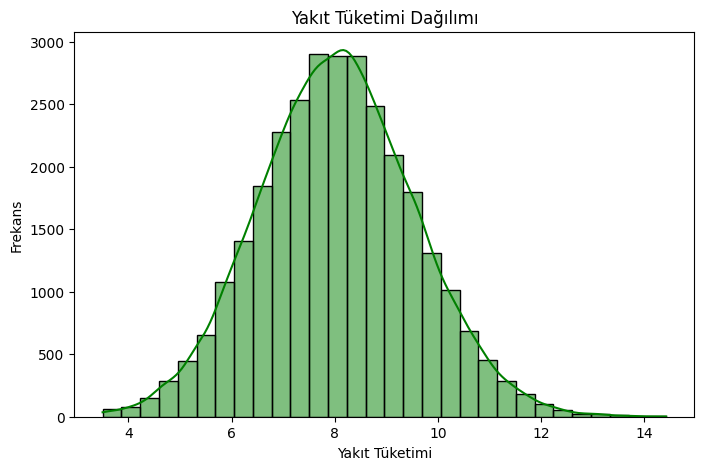

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target Değişkeninin Histogramı
plt.figure(figsize=(8, 5))
sns.histplot(df['fuel_consumption'], bins=30 , kde=True, color='green')
plt.title('Yakıt Tüketimi Dağılımı')
plt.xlabel('Yakıt Tüketimi')
plt.ylabel('Frekans')
plt.show()

**Grafik Yorumum:** Histogram grafiği incelendiğinde, yakıt tüketiminin genel olarak 7 ile 9 litre arasında yoğunlaştığı ve dağılımın çan eğrisi yakın bir eğilim gösterdiğini görebiliriz.

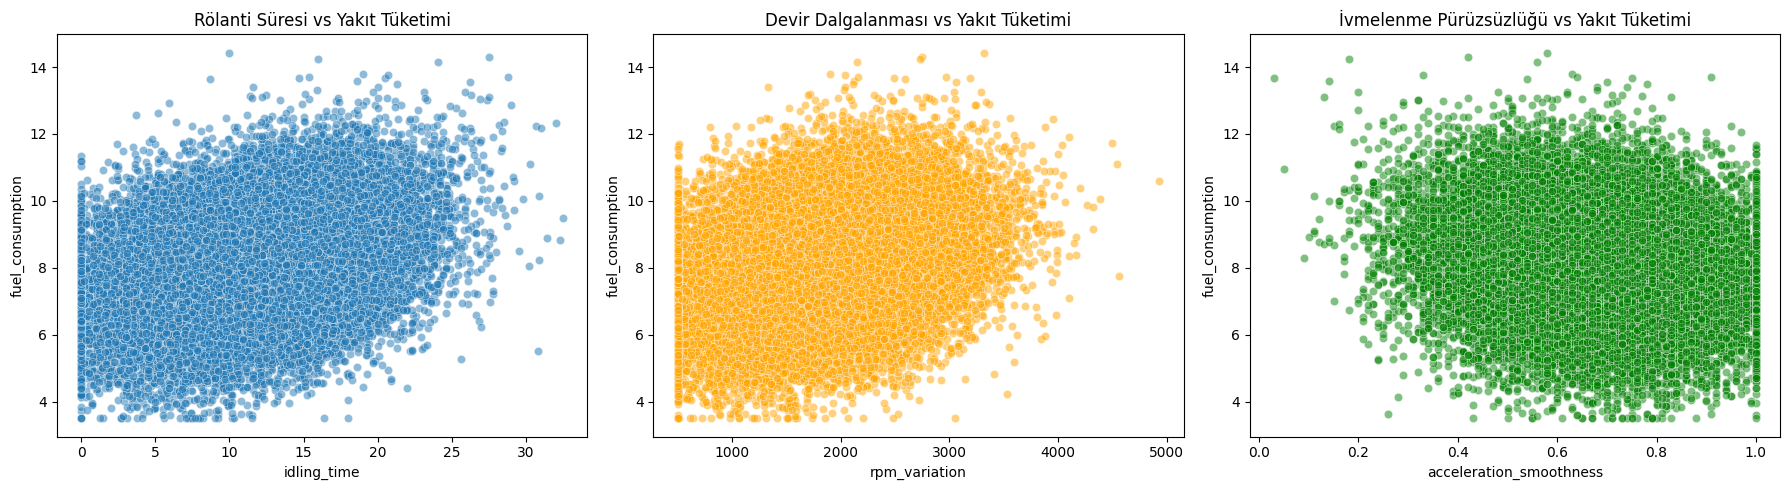

In [6]:
# 2. Scatter Plot: Feature'lar vs Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='idling_time', y='fuel_consumption', ax=axes[0], alpha=0.5)
axes[0].set_title('Rölanti Süresi vs Yakıt Tüketimi')

sns.scatterplot(data=df, x='rpm_variation', y='fuel_consumption', ax=axes[1], alpha=0.5, color='orange')
axes[1].set_title('Devir Dalgalanması vs Yakıt Tüketimi')

sns.scatterplot(data=df, x='acceleration_smoothness', y='fuel_consumption', ax=axes[2], alpha=0.5, color='green')
axes[2].set_title('İvmelenme Pürüzsüzlüğü vs Yakıt Tüketimi')

plt.tight_layout()
plt.show()


**Grafik Yorumum:**
* **Rölanti süresi:** Yükseldikçe yakıt tüketimi değerinin arttığı gözlemlenmekte.
* **Devir dalgalanması:** Arttıkça, yakıt tüketiminde belirgin bir artış gözlemlenmekte hatta pozitif korelasyon var denebilir.
* **İvmelenme pürüzsüzlüğü:** Sürüş pürüzsüzlüğü arttıkça yakıt tüketimi hafif de olsa düşme eğilimindedir ama negatif korelasyon var demek kesin olarak doğru olmaz.

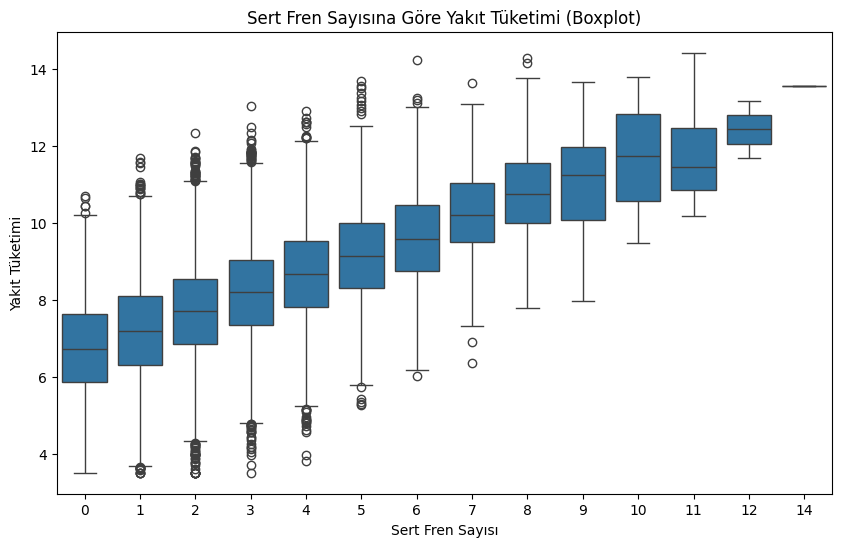

In [7]:
# 3. Boxplot: Sert Fren Sayısına Göre Yakıt Tüketimi
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='harsh_braking_count', y='fuel_consumption')
plt.title('Sert Fren Sayısına Göre Yakıt Tüketimi (Boxplot)')
plt.xlabel('Sert Fren Sayısı')
plt.ylabel('Yakıt Tüketimi')
plt.show()

**Grafik Yorumum:** Boxplot grafiği, sert fren sayısı arttıkça tüketimi medyanının düzenli olarak yükseldiğini somut olarak göstermektedir. Sürücünün agresif frenlemsi doğrudan yüksek tüketim ile ilişkilidir.

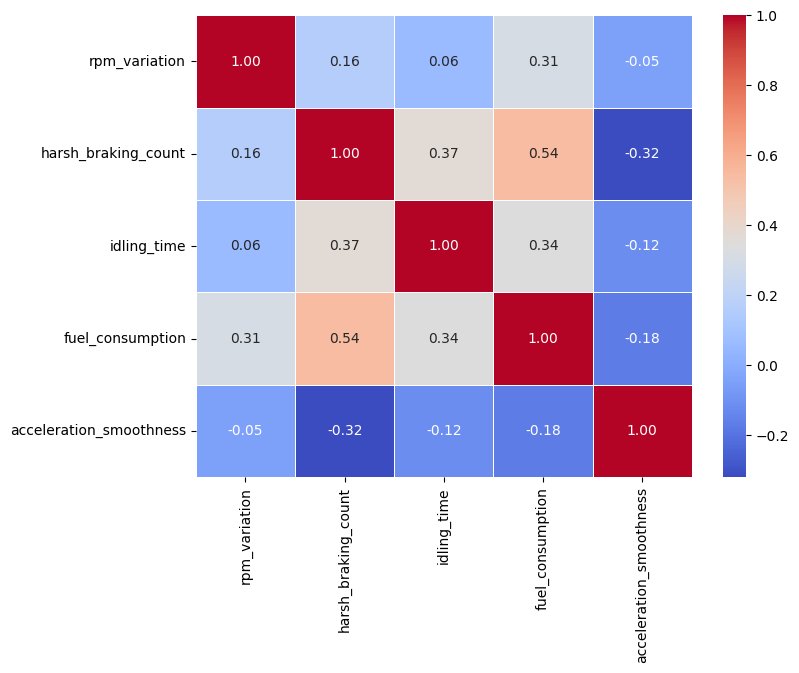

In [8]:
# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df.drop(columns=['eco_score']).corr() # eco_score sütununu veri sızıntısı yapabileceği için şimdilik harita dışı bırakıyorum
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f" , linewidths=0.5)
plt.show()


**Grafik Yorumum:** Isı Haritasına bakarak hedef değişkenimiz olan fueal_consumption ile en güçlü pozitif korelasyon 0.54 katsayısı ile harsh_braking_count değişkenidir diyebiliriz. Bunu 0.34 ile idling_time ve 0.31 ile rpm_variation takip etmektedir. Tüm featureların target ile anlamlı bir korelasyonu vardır

# 4. Gün: Outlier ve Leakage Analysis

Bu aşamada modelimizin öğrenme sürecini bozabilecek aykırı değerleri tespit edip temizleyeceğim. Daha da önemlisi, veri setimizde yer alan `eco_score` değişkeninin doğasını inceleyerek Data Leakage riskini analiz edeceğim.

In [9]:
# Veri seti boyutunu temizlikten önce görelim
print("Temizlik öncesi satır sayısı:", len(df))

# 2.Gün yaptığımız IQR yöntemi ile Aykırı Değerleri filtreleme fonksiyonu
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Sınırlar dışında kalanları at
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Hedef ve Feature sütunlarındaki outlier'ları temizleyelim (eco_score hariç)
columns_to_check = ['rpm_variation', 'harsh_braking_count', 'idling_time', 'fuel_consumption', 'acceleration_smoothness']
df_cleaned = remove_outliers(df, columns_to_check)

print("Temizlik sonrası satır sayısı:", len(df_cleaned))

Temizlik öncesi satır sayısı: 30000
Temizlik sonrası satır sayısı: 29276


### ECO_SCORE VE DATA LEAKAGE DEĞERLENDİRMESİ

* **`eco_score` neyi temsil ediyor?** Sürücünün sürüş ekonomisini ve güvenliğini gösteren, 0 ile 100 arasında değişen genel bir puandır. bu değeri Regresyon modelimizi classification modeline dönüştürmek için kullanabilirim.

* **Nasıl oluşturulmuş olabilir?** Büyük ihtimalle sürüş bittikten sonra; aracın ne kadar yakıt tükettiği, kaç kez sert fren yaptığı ve ne kadar rölantide beklediği gibi metriklerin matematiksel bir formülle birleştirilmesiyle hesaplanmıştır.

* **Data leakage nedir?** Modelin eğitim aşamasında, gerçek dünyada tahmin yapacağı anda elinde bulunmayacak olan veya hedef değişkenin bilgisini zaten içinde barındıran bir veriyi gizlice kullanarak yapay ve yanıltıcı bir şekilde yüksek skor almasıdır.

* **Model için feature olarak kullanılması doğru olur mu?** `eco_score` zaten `fuel_consumption` değerine bakılarak hesaplanan bir puandır. yani yakıt tüketimi değerine bağlıdır bu nedenle bunun bir özellik çıkarımı olamaz. Eğer bunu modele girdi yani feature olarak verirsek, model yakıt tüketimini sürüş davranışlarından öğrenmek yerine doğrudan bu puandan kopya çeker. Gerçek hayatta anlık yakıt tüketimini tahmin etmek istediğimizde elimizde henüz hesaplanmış bir `eco_score` olmayacaktır. Bu yüzden `eco_score` sütunu model eğitimine **dahil etmemeliyiz**.